In [1]:
# Import some useful packages
import os
import matplotlib
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import numpy as np

from scipy import io as sio # only used to load matlab files
from scipy.stats import median_abs_deviation # only used in plot of tail colors I think
from PIL import Image # for udlr # only used in udlr
from plotly.subplots import make_subplots # tetrahedral plots
import seaborn as sns # 2d KDE plots, can also make 2d scatter coloring by factor easier
import pandas as pd # used to generate dataframes/csvs of spectra

# import the generic code for this paper
import hsi.tetra as tetra
import hsi.utils as utils
import hsi.triangle as triangle

# set some defaults for plotting
%matplotlib inline
# Say, "the default sans-serif font is COMIC SANS"
matplotlib.rcParams['font.serif'] = "Times New Roman"
# Then, "ALWAYS use sans-serif fonts"
matplotlib.rcParams['font.family'] = "serif"


In [2]:
# define location for header file, and bil file. We need a full, not a relative filepath
datadir = "D:/Hyperspectral Archive/Bird images/00_00_18"
hdrfile = datadir + "/Gouldian_finch_side.bil.hdr"
bilfile = datadir + "/Gouldian_finch_side.bil"

In [3]:
# Load hyperspectral image as memfile (so we don't need to load it into memory)
img = envi.open(hdrfile, bilfile) # see https://www.spectralpython.net/fileio.html
# It can be handy to collect the wavelength bands from the image for later use
owl = img.bands.centers
print(img.shape)

(1368, 537, 294)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


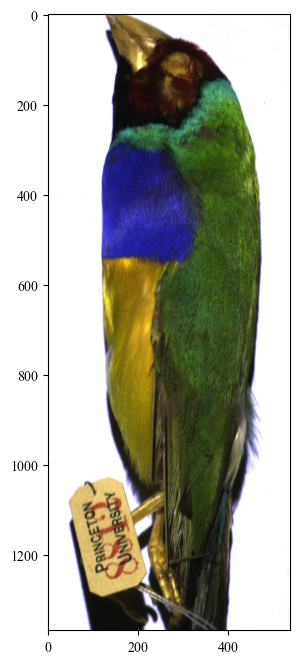

In [5]:
# Plot a xample false color image of the file
fig, ax, rgb_im = utils.PlotFalseRGB(img, r = 600., g = 550., b = 425., standard_100 = np.repeat(4, len(owl)), plotme = True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


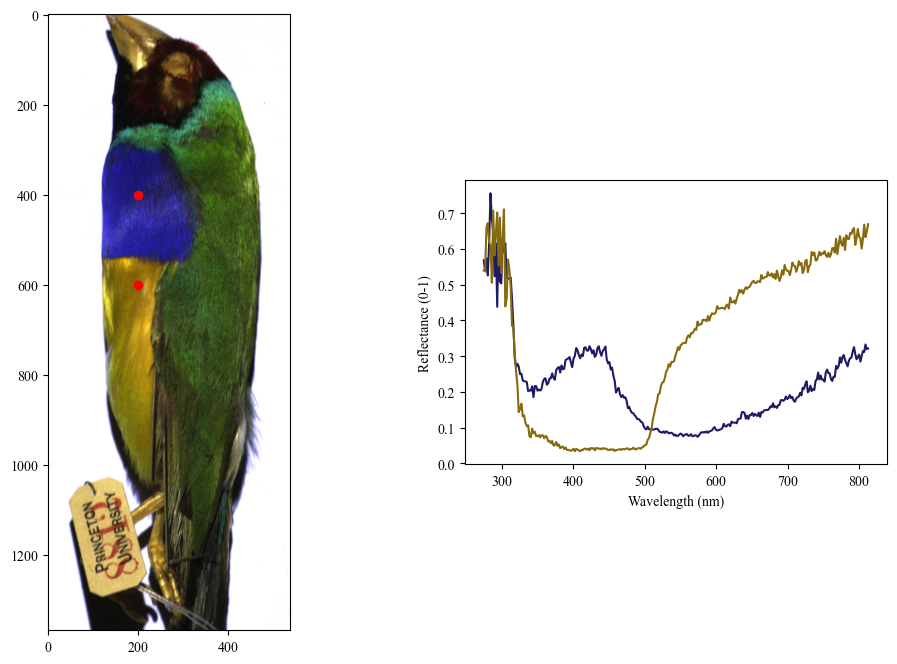

In [6]:
#### Example extraction of single points

y = [400, 600]
x = [200, 200]

# Init empty n sample by wl array
Specs = np.empty((len(x), len(img.bands.centers)))
Specs[:] = np.NaN
RGBs = np.empty((len(x), 3))

# Load each in loop, it is possible to load defined sections with for instance 
# img.read_subregion(col_bounds = [xmi, xma], row_bounds = [ymi, yma], use_memmap=True)
for i in range(Specs.shape[0]):
    Specs[i,:] = img[y[i], x[i], :].flatten()
    # lets grab out the R,G,B levels at those samples, for simplicity
    RGBs[i,:] = rgb_im[y[i], x[i]]

#### Plot those samples

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(12,8), dpi=100, facecolor='w', edgecolor='k')

# show sampled locations
ax[0].imshow(rgb_im);
ax[0].scatter(x,y, c = 'red');

# Plot the spectra
for i in range(len(x)):
    ax[1].plot(owl, Specs[i,:], color = RGBs[i]) # color spectra by the rgb from the image
    
ax[1].set_xlabel('Wavelength (nm)')
ax[1].set_ylabel('Reflectance (0-1)')
ax[1].set_aspect(500)

Samples need averaging
Processing and averaging
Averaging 0 of 2


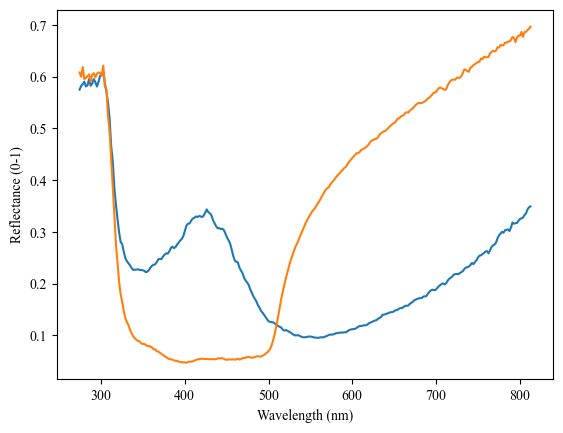

In [7]:
## Alternatively, use our utility function to sample the same locations
# but with convenient spatial sampling (here 10x10 block averaged)

# read bands at x, y coordinates, and spatially average 3x3 square at those locations, then plot
Specs = utils.ReadBands(img, x, y, 10)
utils.PlotSpec(Specs = Specs, wl = img.bands.centers)

In [10]:
# We can save the kinds of spectra out for use in spectrum based analyses like pavo
r_spec = pd.DataFrame(Specs.T, index = img.bands.centers)
r_spec.columns = ['a', 'b']
r_spec.to_csv("../out/Ranalysis/example_spec.csv")

Samples need averaging
Processing and averaging
Averaging 0 of 315
Averaging 100 of 315
Averaging 200 of 315


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Averaging 300 of 315


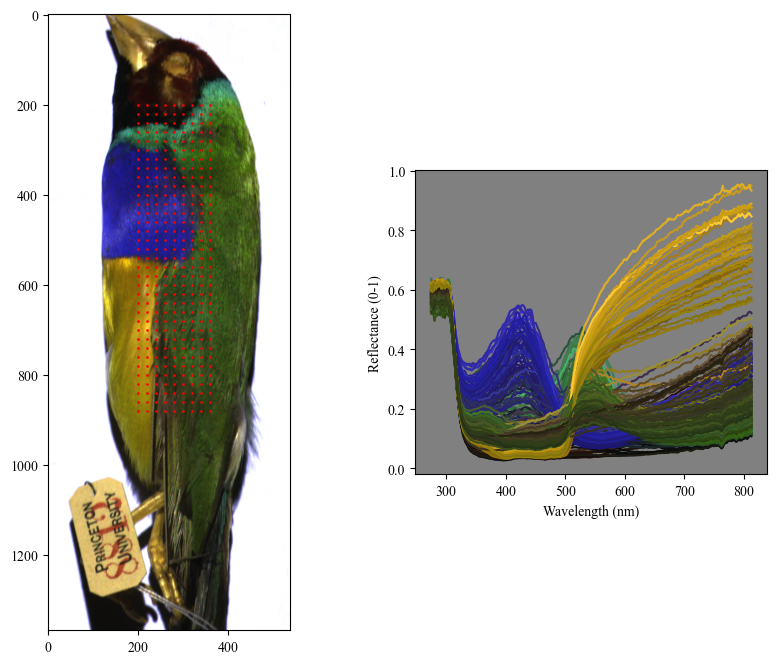

In [13]:
# lets define a regions to sample from instead
xmi, xma = [200, 370]
ymi, yma = [200, 900]

# alternatively, could sample whole image
# xmi, xma = [0, img.shape[1]]
# ymi, yma = [0, img.shape[0]]

# or one could load a whole region (i.e. not sample):
# Specs = img.read_subregion(col_bounds = [xmi, xma], row_bounds = [ymi, yma], use_memmap=True)
# Specs = Specs.reshape([Specs.shape[0]*Specs.shape[1],Specs.shape[2]])

# let's just grab a subset of those with defined gaps
gap = 20
x = np.arange(xmi, xma, step = gap)
y = np.arange(ymi, yma, step = gap)
xx, yy = np.meshgrid(x,y)
xx = xx.flatten()
yy = yy.flatten()

# Init empty n sample by wl array
Specs = utils.ReadBands(img, xx, yy, 10)
RGBs = np.empty((len(xx), 3))

# grab the rgb color in loop
for i in range(Specs.shape[0]):
    RGBs[i,:] = rgb_im[yy[i], xx[i]]
RGBs[RGBs>1]=1

## Plot the results
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(10, 8), dpi=100, facecolor='w', edgecolor='k')

# show sampled locations
ax[0].imshow(rgb_im);
ax[0].scatter(xx, yy, s = 0.75, c = 'r');

# Plot the spectra
for i in range(len(xx)):
    ax[1].plot(owl, Specs[i,:], color = RGBs[i]) # color spectra by the rgb from the image
    
ax[1].set_xlabel('Wavelength (nm)')
ax[1].set_ylabel('Reflectance (0-1)')
ax[1].set_aspect(500)
ax[1].set_facecolor("gray")

In [14]:
# We can interpolate the spectra to 1nm and remove <325nm and >700
int_wl, int_Specs = utils.InterpSample(owl, Specs, wlnew = np.arange(325, 700, 1) )

In [15]:
# generate KLPD, dSh, and dW for those sampled spectra
pca = utils.EmbedPCA(int_Specs) # here, we cut below 325 nm for noise-reduction
# generate a umap embedding of the dSh distance
pca_umap_embedded = utils.EmbedDist(Coordinates = pca, verbose = 0)


Computing umap on coordinates
UMAP done in 3.154635190963745


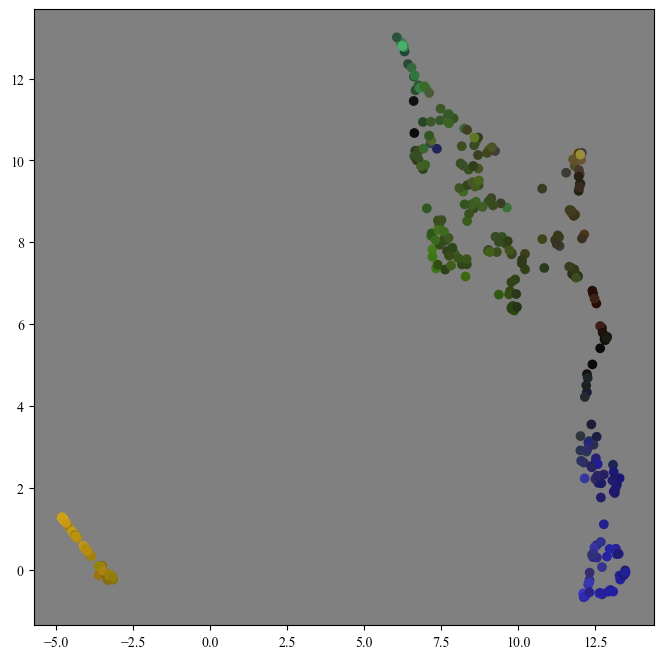

In [16]:
# plot that embedding, with RGB from the falsecolor image
fig, ax = plt.subplots(figsize = [8,8])
ax.set_facecolor([0.5,0.5,0.5])
ax.scatter(pca_umap_embedded[:,0], pca_umap_embedded[:,1], color = RGBs)

In [17]:
# Okay, so instead lets get ready to make a montage of slices

# generate a nice rainbow colormap 
custom_map = utils.GetCustomColormap()

# Define the grid for the montage
nrow = 1
ncol = 9
nwl = nrow * ncol
imw = img.shape[1]
imh = img.shape[0]
wwidth = ncol * (imw/imh)
wheight = nrow
wwidth = wwidth/wheight
wheight = wheight/wheight

# Work out what wavlength band images we'll want in our montage
minwl = 330
maxwl = 700
levs = np.linspace(minwl, maxwl, nwl)
levs = np.append(330, np.arange(350, 710, 50))
print(levs)
idxl = []
for i in levs:
    idxl.append(np.argmin(np.abs(owl - i)))
rgba = custom_map(np.linspace(0,1,len(levs)))


[330 350 400 450 500 550 600 650 700]


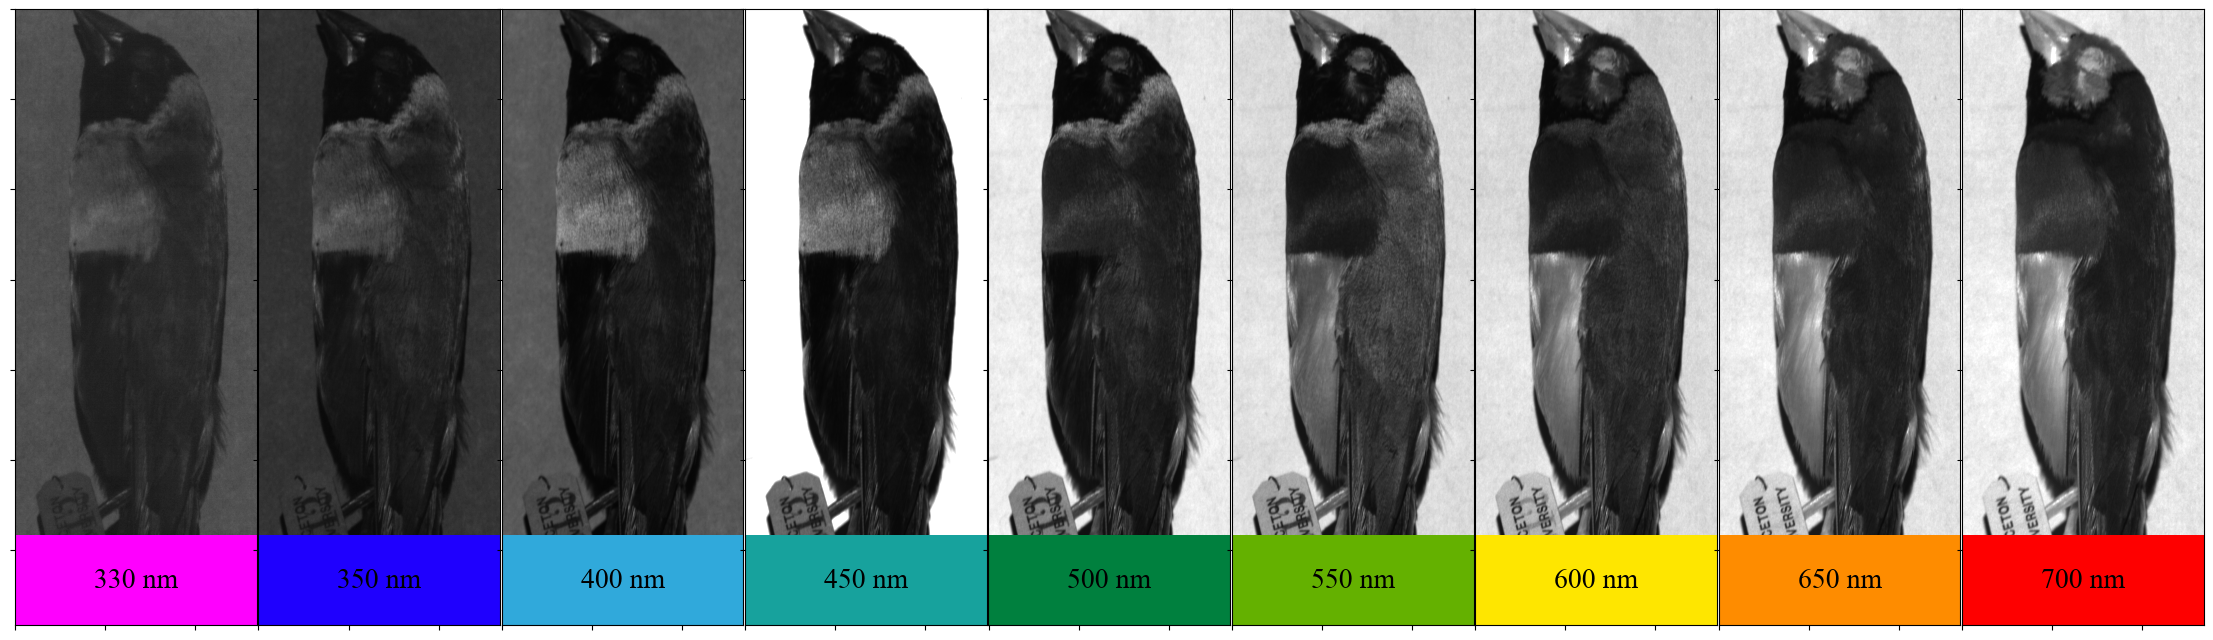

In [61]:
# plot our montage
fig, axs = plt.subplots(nrow, ncol, figsize=[wwidth * 8,wheight * 8], dpi=100, facecolor='w', edgecolor='k') # n by n*3.38
for i, ax in enumerate(fig.axes):
    
    # grab the image at each band closest to the selected wavelengths
    gray_img = img[:,:,int(idxl[i])]
    ax.imshow(gray_img, cmap='gray', vmin = 0, vmax = 1)

    # add rectangle with wavelenth label
    rect = plt.Rectangle((0,img.shape[0]-200), gray_img.shape[1], 200, facecolor=rgba[i])
    ax.add_patch(rect)
    ax.text(img.shape[1]/2, img.shape[0]-100,  str(levs[i].astype(int)) + " nm", verticalalignment = 'center', horizontalalignment='center', fontsize = 20)

    # format axes
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')
    
plt.subplots_adjust(wspace=0, hspace=0)

fig.savefig('../Figures/Diagram/Montage_plot_gould.pdf', dpi = 200,bbox_inches='tight')

In [ ]:
## What follows is an example of converting a hyperspectral image into a cone-catch image compatible with MICA/QCPA

from tqdm import tqdm

# load visual sensitivity (in this case, average uv bird cones)
df = pd.read_csv( '../dat/Sensi/Avg_v.csv', index_col=None).to_numpy()
wl = df[:,0]
df = df[:,1:]

# interpolate visual sensitivity to wavelengths of 325>x<700, otherwise matching the band centers of the hyperspectral image
# an alternative might be to interpolate/extrapolate the entire hyperspectral image to match the sensitivity
wl, df = utils.InterpSample(wl, df.T, wlnew = owl[np.logical_and(owl > 325, owl < 700)])
df = np.divide(df, np.sum(df, axis = 1)[:,None]) # normalize to area = 1

plot, and print shape
plt.plot(wl, df.T)
print(df.shape)

# go through pixels of our hyperspectral image, and for each find usml value out (integration by multiplication)
nrows = img.shape[0]
ncols = img.shape[1]
chans = df.shape[0]
x_out = np.zeros((nrows, ncols, chans + 1)) # note that QCPA expects last channel to be luminance, which we don't use here, but could do if we added a 5th color sensitivity channel

for i in tqdm(range(nrows)): # tqdm displays a timer for the processing
    for j in range(ncols): 
        x = img[i, j]
        x = x[np.logical_and(owl > 325, owl < 700)]
        x_out[i,j,:] = np.sum(x * df, axis = 1) # integration by sum, here one could introduce an illuminant or background adaptation

# plot the resulting images
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (10,10))
vmin = 0
vmax = 1
a = ax[0].imshow(x_out_norm[:,:,0], vmin = vmin, vmax = vmax)
ax[1].imshow(x_out[:,:,1], vmin = vmin, vmax = vmax)
ax[2].imshow(x_out[:,:,2], vmin = vmin, vmax = vmax)
ax[3].imshow(x_out[:,:,3], vmin = vmin, vmax = vmax)
cax = fig.add_axes([0.85, 0, 0.1, 1])
fig.colorbar(a, ax=cax)
cax.set_axis_off()

# make a version that is an unsigned 32 bit image and save it out
x_out_norm = x_out
x_out_norm[x_out_norm > 1] = 1
x_out_norm = x_out_norm * 2**32
x_out_norm = x_out_norm.astype('float32')
print(x_out_norm.dtype) 

im = Image.fromarray(x_out_norm[:,:,0])
imlist = []
for m in range(chans):
    imlist.append(Image.fromarray(x_out_norm[:,:,m]))

# save that out as a multi-page tiff to use in mica/QCPA
imlist[0].save("../out/test.tif", compression="None", save_all=True,
               append_images=imlist[1:])